In [2]:
import matplotlib.pyplot as plt

# Plotting style
import seaborn as sns
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

import pandas as pd
import numpy as np
import statsmodels.api as sm

> Indlæs data

In [3]:
df = pd.read_csv("day.csv")

# Displaying the dataframe.
display(df.tail())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


For at gøre datasættet lettere at fortolke går vi tilbage til datasættet uden normalisering (bruger værdier fra Readme)

In [4]:
df['temp'] = df['temp'] * 41
df['atemp'] = df['atemp'] * 50
df['hum'] = df['hum'] * 100
df['windspeed'] = df['windspeed'] * 67

In [5]:
display(df.tail())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,8.849153,11.17435,57.7500,10.374682,439,2290,2729


In [6]:
# antal observationer
df.size

11696

In [7]:
#antal rækker og kolonner 
df.shape

(731, 16)

In [8]:
# antal missing values i hver kolonne
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

# a) Descriptive statistics

In [9]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,20.310776,23.717699,62.789406,12.762576,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,7.505091,8.148059,14.242910,5.192357,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.820424,16.892125,52.000000,9.041650,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,20.431653,24.336650,62.666700,12.125325,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.872076,30.430100,73.020850,15.625371,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [10]:
# Vælg de kolonner du vil kigge på
cols = ['cnt', 'temp', 'atemp', 'hum', 'windspeed']

In [11]:
#Kode til at lave en latex tabel med beskrivende statistik for de valgte kolonner
summary = df[cols].describe().T
print(summary.to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrrrr}
\toprule
 & count & mean & std & min & 25% & 50% & 75% & max \\
\midrule
cnt & 731.00 & 4504.35 & 1937.21 & 22.00 & 3152.00 & 4548.00 & 5956.00 & 8714.00 \\
temp & 731.00 & 20.31 & 7.51 & 2.42 & 13.82 & 20.43 & 26.87 & 35.33 \\
atemp & 731.00 & 23.72 & 8.15 & 3.95 & 16.89 & 24.34 & 30.43 & 42.04 \\
hum & 731.00 & 62.79 & 14.24 & 0.00 & 52.00 & 62.67 & 73.02 & 97.25 \\
windspeed & 731.00 & 12.76 & 5.19 & 1.50 & 9.04 & 12.13 & 15.63 & 34.00 \\
\bottomrule
\end{tabular}



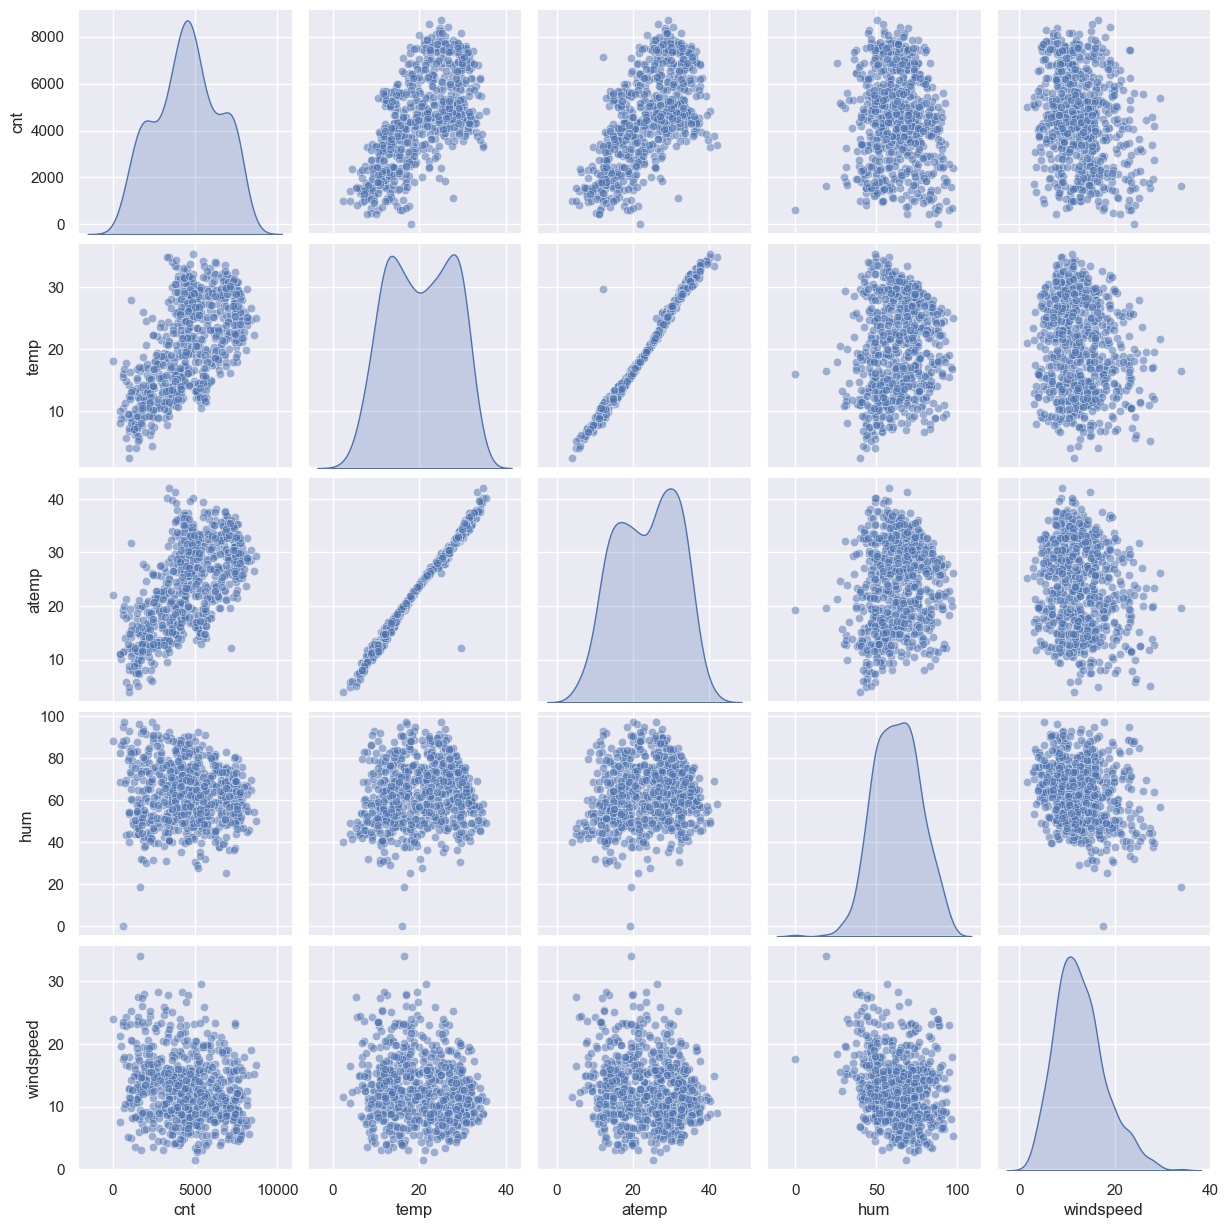

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lav et pairplot
sns.pairplot(df[cols], diag_kind='kde', plot_kws={'alpha': 0.5})

plt.savefig("pairplot2.png", bbox_inches='tight')  
plt.show()

Valg af afhængig variabel

In [13]:
print(df.columns)
yVar = "cnt" 

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')


Korrelationskoefficienter mellem uafhængige variable og yVar

In [14]:
df.corr(numeric_only=True)[yVar]

instant       0.628830
season        0.406100
yr            0.566710
mnth          0.279977
holiday      -0.068348
weekday       0.067443
workingday    0.061156
weathersit   -0.297391
temp          0.627494
atemp         0.631066
hum          -0.100659
windspeed    -0.234545
casual        0.672804
registered    0.945517
cnt           1.000000
Name: cnt, dtype: float64

Variable som ikke giver mening at lave korrelation på fjernes så vi kigger på kontinuerte:

In [15]:
df[cols].corr()[yVar]


cnt          1.000000
temp         0.627494
atemp        0.631066
hum         -0.100659
windspeed   -0.234545
Name: cnt, dtype: float64

In [49]:
corr = df[['cnt','atemp', 'temp','hum','windspeed']].corr()
print(corr)

                cnt     atemp      temp       hum  windspeed
cnt        1.000000  0.631066  0.627494 -0.100659  -0.234545
atemp      0.631066  1.000000  0.991702  0.139988  -0.183643
temp       0.627494  0.991702  1.000000  0.126963  -0.157944
hum       -0.100659  0.139988  0.126963  1.000000  -0.248489
windspeed -0.234545 -0.183643 -0.157944 -0.248489   1.000000


In [52]:
corr.index = ['cnt','atemp', 'Temp','hum','windspeed']
corr.columns = ['cnt','atemp', 'Temp','hum','windspeed']

print(corr.to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrr}
\toprule
 & cnt & atemp & Temp & hum & windspeed \\
\midrule
cnt & 1.00 & 0.63 & 0.63 & -0.10 & -0.23 \\
atemp & 0.63 & 1.00 & 0.99 & 0.14 & -0.18 \\
Temp & 0.63 & 0.99 & 1.00 & 0.13 & -0.16 \\
hum & -0.10 & 0.14 & 0.13 & 1.00 & -0.25 \\
windspeed & -0.23 & -0.18 & -0.16 & -0.25 & 1.00 \\
\bottomrule
\end{tabular}



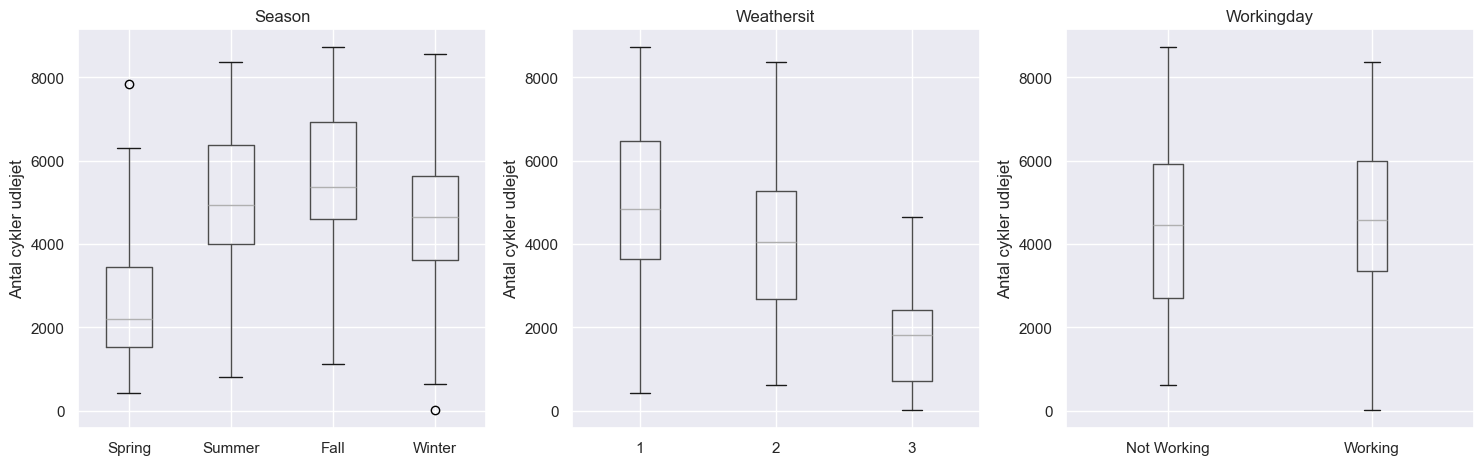

In [ ]:
df['season_label'] = pd.Categorical(
    df['season'].map({
        1: 'Spring',
        2: 'Summer',
        3: 'Fall',
        4: 'Winter'
    }),
    categories=['Spring', 'Summer', 'Fall', 'Winter'],
    ordered=True
)

df['workingday_label'] = df['workingday'].map({
        0: 'Not Working',
        1: 'Working'
    })

fig, axes = plt.subplots(1, 3, figsize=(15,5))

variables = ['season_label', 'weathersit', 'workingday_label']
name = ['Season', 'Weathersit', 'Workingday']

for i, var in enumerate(variables):
    df.boxplot(column='cnt', by=var, ax=axes[i])
    axes[i].set_title(name[i])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Antal cykler udlejet')

plt.suptitle('')
plt.tight_layout()
plt.savefig("boxplot2.png", bbox_inches='tight')  
plt.show()

In [19]:
#Ser at 4 ikke optræder i weathersit boxplottet og tjekker om det er en fejl
df['weathersit'].unique()

array([2, 1, 3])

# b) Estimate a supervised model

Vi bruger fra nu af atemp og ikke temp for at undgå multikolinaritet. På samme måde arbejder vi videre med season og ikke måneder

## Transformation og interaktionsled

> Vi tester for relevante transformationer og interaktionsled

In [20]:
import statsmodels.formula.api as smf

atemp_lin = smf.ols('cnt ~ atemp', data=df).fit()
print(atemp_lin.summary())


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     482.5
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.85e-82
Time:                        13:34:07   Log-Likelihood:                -6384.0
No. Observations:                 731   AIC:                         1.277e+04
Df Residuals:                     729   BIC:                         1.278e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    945.8240    171.291      5.522      0.0

In [21]:
atemp_quad = smf.ols('cnt ~ atemp + I(atemp**2)', data=df).fit()
print(atemp_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     296.5
Date:                Sun, 03 May 2026   Prob (F-statistic):           6.41e-95
Time:                        13:34:07   Log-Likelihood:                -6351.9
No. Observations:                 731   AIC:                         1.271e+04
Df Residuals:                     728   BIC:                         1.272e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -2155.0969    413.033     -5.218

kvadratledet er negativt (konkav). Efterspørgslen stiger med temperaturen til et hvis punkt hvor det derefter falder

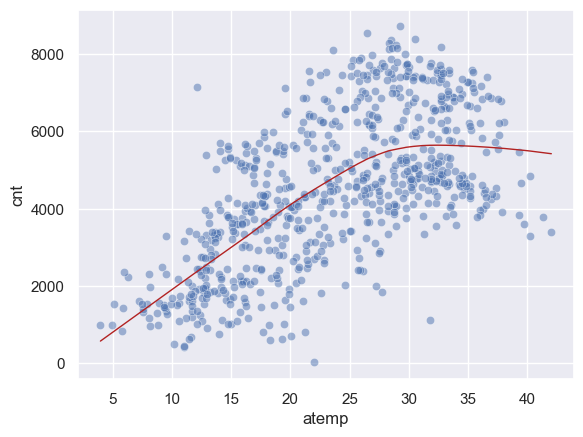

In [22]:
sns.scatterplot(x='atemp', y='cnt', data=df, color=sns.color_palette()[0], alpha=0.5)
sns.regplot(x='atemp', y='cnt', data=df, lowess=True, scatter=False, color='firebrick', line_kws={'linewidth': 1})
plt.savefig("atemp.png", bbox_inches='tight') 

In [23]:
hum_lin = smf.ols('cnt ~ hum', data=df).fit()
print(hum_lin.summary())


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     7.462
Date:                Sun, 03 May 2026   Prob (F-statistic):            0.00645
Time:                        13:34:08   Log-Likelihood:                -6566.0
No. Observations:                 731   AIC:                         1.314e+04
Df Residuals:                     729   BIC:                         1.315e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5363.9865    322.679     16.623      0.0

In [24]:
hum_quad = smf.ols('cnt ~ hum + I(hum**2)', data=df).fit()
print(hum_quad.summary())


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     30.86
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.37e-13
Time:                        13:34:08   Log-Likelihood:                -6539.9
No. Observations:                 731   AIC:                         1.309e+04
Df Residuals:                     728   BIC:                         1.310e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -1245.5145    954.185     -1.305      

<Axes: xlabel='hum', ylabel='cnt'>

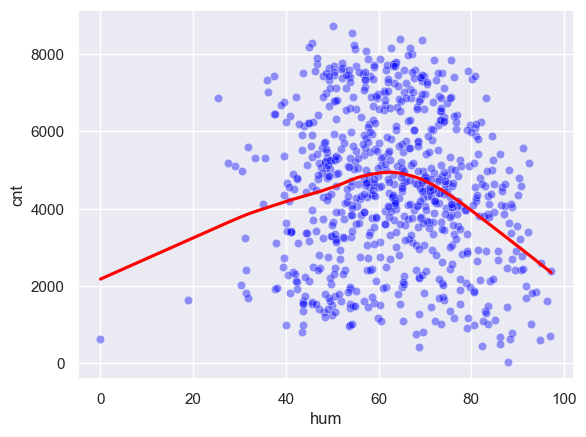

In [25]:
sns.scatterplot(x='hum', y='cnt', data=df, color='blue', alpha=0.4)
sns.regplot(x='hum', y='cnt', data=df, lowess=True, scatter=False, color='red')

Meget lav forklaring generalt. Måske ikke den vigtigste variabel

<Axes: xlabel='windspeed', ylabel='cnt'>

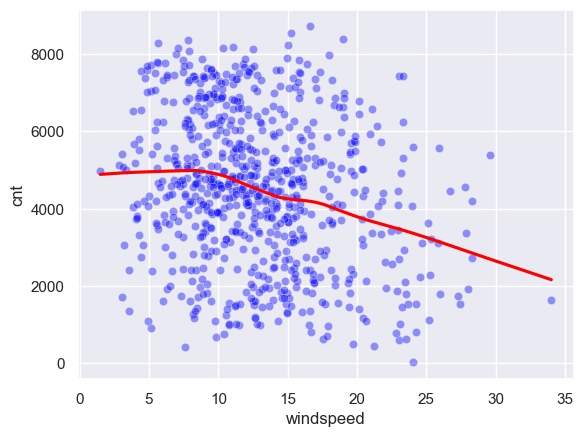

In [26]:
sns.scatterplot(x='windspeed', y='cnt', data=df, color='blue', alpha=0.4)
sns.regplot(x='windspeed', y='cnt', data=df, lowess=True, scatter=False, color='red')

In [27]:
windspeed_lin = smf.ols('cnt ~ windspeed', data=df).fit()
print(windspeed_lin.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     42.44
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.36e-10
Time:                        13:34:08   Log-Likelihood:                -6549.0
No. Observations:                 731   AIC:                         1.310e+04
Df Residuals:                     729   BIC:                         1.311e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5621.1529    185.062     30.374      0.0

In [28]:
windspeed_quad = smf.ols('cnt ~ windspeed + I(windspeed**2)', data=df).fit()
print(windspeed_quad.summary())


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     22.35
Date:                Sun, 03 May 2026   Prob (F-statistic):           3.80e-10
Time:                        13:34:09   Log-Likelihood:                -6547.9
No. Observations:                 731   AIC:                         1.310e+04
Df Residuals:                     728   BIC:                         1.312e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          5124.3476    382.96

In [29]:
atempogseason = smf.ols('cnt ~ atemp + C(season)', data=df).fit()
print(atempogseason.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     151.2
Date:                Sun, 03 May 2026   Prob (F-statistic):           4.70e-94
Time:                        13:34:09   Log-Likelihood:                -6348.2
No. Observations:                 731   AIC:                         1.271e+04
Df Residuals:                     726   BIC:                         1.273e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        603.3266    198.358      3.

In [30]:
atempxseason = smf.ols('cnt ~ atemp * C(season)', data=df).fit()
print(atempxseason.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                     96.93
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.51e-99
Time:                        13:34:09   Log-Likelihood:                -6327.8
No. Observations:                 731   AIC:                         1.267e+04
Df Residuals:                     723   BIC:                         1.271e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             -175.8851 

Nu bliver season 2 ikke signifikant. Det tyder på at den ikke har en konstant effekt men en effekt der afhænger af temperatur

In [31]:
holiday = smf.ols('cnt ~ holiday', data=df).fit()
print(holiday.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     3.421
Date:                Sun, 03 May 2026   Prob (F-statistic):             0.0648
Time:                        13:34:09   Log-Likelihood:                -6568.0
No. Observations:                 731   AIC:                         1.314e+04
Df Residuals:                     729   BIC:                         1.315e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4527.1042     72.582     62.372      0.0

Selvom fortegn giver mening for holiday bliver en del af den forklaret gennem season og workingday og den inkluderes derfor ikke 

In [32]:
atempogweathersit = smf.ols('cnt ~ atemp + C(weathersit)', data=df).fit()
print(atempogweathersit.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     204.7
Date:                Sun, 03 May 2026   Prob (F-statistic):           3.10e-96
Time:                        13:34:09   Log-Likelihood:                -6345.9
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     727   BIC:                         1.272e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           1371.7393    173

In [33]:
atempxweathersit = smf.ols('cnt ~ atemp * C(weathersit)', data=df).fit()
print(atempxweathersit.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.460
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     123.4
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.97e-94
Time:                        13:34:09   Log-Likelihood:                -6344.7
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     725   BIC:                         1.273e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Interaktionsledet mellem temperaturen og weathersit er ikke signifikant

> De tre kontinuerte variable plottet mod cnt gør transformationen

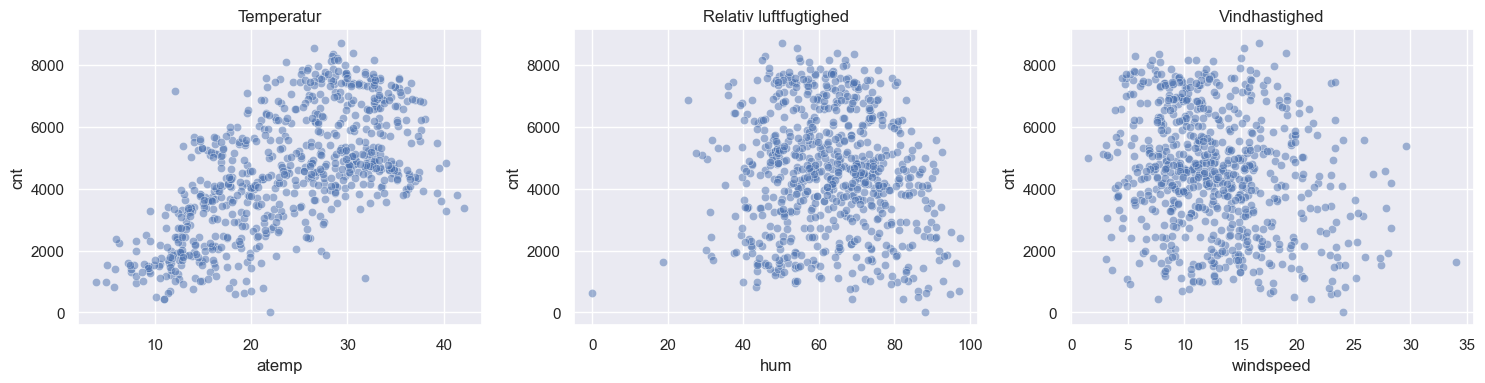

In [34]:


blue = sns.color_palette()[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# atemp
sns.scatterplot(x='atemp', y='cnt', data=df, color=blue, alpha=0.5, ax=axes[0])
axes[0].set_title('Temperatur')

# hum
sns.scatterplot(x='hum', y='cnt', data=df, color=blue, alpha=0.5, ax=axes[1])
axes[1].set_title('Relativ luftfugtighed')

# windspeed
sns.scatterplot(x='windspeed', y='cnt', data=df, color=blue, alpha=0.5, ax=axes[2])
axes[2].set_title('Vindhastighed')

plt.tight_layout()
plt.savefig("3plots.png", bbox_inches='tight')
plt.show()

## Foward selection

In [35]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

target = 'cnt'

predictors = [
    'atemp',
    'I(atemp**2)',
    'hum',
    'windspeed',
    'C(season)',
    'C(weathersit)',
    'workingday',
    'atemp:C(season)'
]

df_clean = df.dropna(subset=['cnt', 'atemp', 'hum', 'windspeed', 
                             'season', 'weathersit', 'workingday'])

def forward_selection(df, target, predictors):
    remaining = set(predictors)
    selected = []
    current_score = 0.0
    results = []

    dependencies = {
        'I(atemp**2)': ['atemp'],
        'atemp:C(season)': ['atemp', 'C(season)'],
        'atemp:C(weathersit)': ['atemp', 'C(weathersit)']
    }

    while remaining:
        print(f"\nStep with selected: {selected}")
        scores_with_candidates = []

        for candidate in remaining:
            required_vars = dependencies.get(candidate, [])
            missing_deps = [var for var in required_vars if var not in selected]

            if missing_deps:
                print(f"  Testing {candidate}: SKIPPED (requires {missing_deps})")
                continue

            if selected:
                formula = f"{target} ~ " + " + ".join(selected + [candidate])
            else:
                formula = f"{target} ~ {candidate}"

            model = sm.OLS.from_formula(formula, data=df).fit()
            score = model.rsquared_adj
            scores_with_candidates.append((score, candidate))
            print(f"  Testing {candidate}: Adjusted R² = {score:.4f}")

        if not scores_with_candidates:
            break

        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates.pop()

        print(f"  Best candidate: {best_candidate} with Adjusted R² = {best_new_score:.4f}")

        if best_new_score > current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
            results.append((selected.copy(), current_score))
        else:
            break

    return results

selection_results = forward_selection(df_clean, target, predictors)

print("Forward Selection Results:")
for i, (vars, adj_r2) in enumerate(selection_results, 1):
    print(f"Step {i}: Variables: {vars}, Adjusted R²: {adj_r2:.4f}")

if selection_results:
    final_vars = selection_results[-1][0]
    formula = f"{target} ~ " + " + ".join(final_vars)
    final_model = sm.OLS.from_formula(formula, data=df_clean).fit()

    print("\nFinal Model Summary:")
    print(final_model.summary())


Step with selected: []
  Testing atemp:C(season): SKIPPED (requires ['atemp', 'C(season)'])
  Testing workingday: Adjusted R² = 0.0024
  Testing I(atemp**2): SKIPPED (requires ['atemp'])
  Testing hum: Adjusted R² = 0.0088
  Testing C(season): Adjusted R² = 0.3443
  Testing atemp: Adjusted R² = 0.3974
  Testing windspeed: Adjusted R² = 0.0537
  Testing C(weathersit): Adjusted R² = 0.0967
  Best candidate: atemp with Adjusted R² = 0.3974

Step with selected: ['atemp']
  Testing atemp:C(season): SKIPPED (requires ['C(season)'])
  Testing workingday: Adjusted R² = 0.3974
  Testing I(atemp**2): Adjusted R² = 0.4474
  Testing hum: Adjusted R² = 0.4331
  Testing C(season): Adjusted R² = 0.4515
  Testing windspeed: Adjusted R² = 0.4112
  Testing C(weathersit): Adjusted R² = 0.4557
  Best candidate: C(weathersit) with Adjusted R² = 0.4557

Step with selected: ['atemp', 'C(weathersit)']
  Testing atemp:C(season): SKIPPED (requires ['C(season)'])
  Testing workingday: Adjusted R² = 0.4568
  Tes

Tager udgangspunkt i modellen fra step 7

In [36]:
model1 = smf.ols('cnt ~ atemp + C(weathersit) + I(atemp**2) + C(season) + hum + atemp:C(season) + windspeed', data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     93.62
Date:                Sun, 03 May 2026   Prob (F-statistic):          6.39e-138
Time:                        13:34:11   Log-Likelihood:                -6225.5
No. Observations:                 731   AIC:                         1.248e+04
Df Residuals:                     718   BIC:                         1.254e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1386.2683 

In [37]:
df['season_2'] = (df['season'] == 2).astype(int)
df['season_3'] = (df['season'] == 3).astype(int)
df['season_4'] = (df['season'] == 4).astype(int)

df['weathersit_2'] = (df['weathersit'] == 2).astype(int)
df['weathersit_3'] = (df['weathersit'] == 3).astype(int)


In [38]:
model2 = smf.ols('cnt ~ atemp + weathersit_3 + I(atemp**2) + C(season) + hum + atemp:C(season) + windspeed', data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     101.5
Date:                Sun, 03 May 2026   Prob (F-statistic):          3.40e-138
Time:                        13:34:11   Log-Likelihood:                -6227.2
No. Observations:                 731   AIC:                         1.248e+04
Df Residuals:                     719   BIC:                         1.253e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1567.7311 

In [39]:
model3 = smf.ols('cnt ~ atemp + C(weathersit) + I(atemp**2) + season_3 + season_4 + hum + atemp:season_3 + atemp:season_4 + windspeed', data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     110.0
Date:                Sun, 03 May 2026   Prob (F-statistic):          9.83e-138
Time:                        13:34:11   Log-Likelihood:                -6230.7
No. Observations:                 731   AIC:                         1.248e+04
Df Residuals:                     720   BIC:                         1.253e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           1171.5702    487

In [40]:
model4 = smf.ols('cnt ~ atemp + C(weathersit) + I(atemp**2) + season_3 + season_4 + hum + atemp:season_3 + windspeed', data=df).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     122.3
Date:                Sun, 03 May 2026   Prob (F-statistic):          9.64e-139
Time:                        13:34:11   Log-Likelihood:                -6230.8
No. Observations:                 731   AIC:                         1.248e+04
Df Residuals:                     721   BIC:                         1.253e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           1199.9045    483

In [41]:
model5 = smf.ols('cnt ~ atemp + weathersit_3 + I(atemp**2) + season_3 + season_4 + hum + atemp:season_3  + windspeed', data=df).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     137.0
Date:                Sun, 03 May 2026   Prob (F-statistic):          3.10e-139
Time:                        13:34:11   Log-Likelihood:                -6232.2
No. Observations:                 731   AIC:                         1.248e+04
Df Residuals:                     722   BIC:                         1.252e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       1383.4403    471.370      2.

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = model5.model.exog
names = model5.model.exog_names

vif_df = pd.DataFrame({
    'variable': names,
    'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})

print(vif_df)

         variable         VIF
0       Intercept  107.765698
1           atemp   60.146202
2    weathersit_3    1.139448
3   I(atemp ** 2)   74.709213
4        season_3   97.919269
5        season_4    1.313498
6             hum    1.270842
7  atemp:season_3  114.317165
8       windspeed    1.171657


## C) Final model and model control

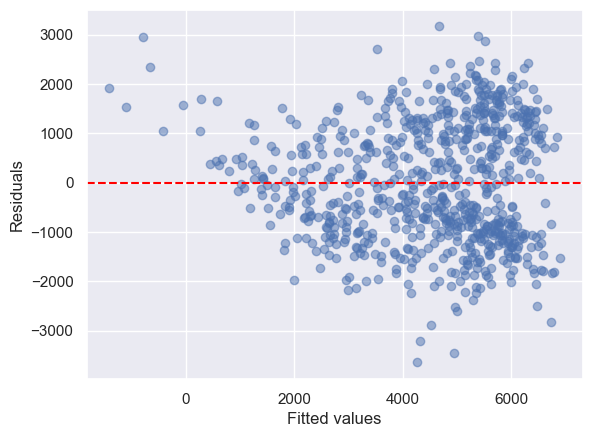

In [43]:
plt.scatter(model5.fittedvalues, model5.resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

In [44]:
df['log_cnt'] = np.log(df['cnt'])

model6 = smf.ols('log_cnt ~ atemp + weathersit_3 + I(atemp**2) + season_3 + season_4 + hum + atemp:season_3 + windspeed', data=df).fit()
print(model6.summary())

                            OLS Regression Results                            
Dep. Variable:                log_cnt   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     153.0
Date:                Sun, 03 May 2026   Prob (F-statistic):          7.32e-150
Time:                        13:34:12   Log-Likelihood:                -280.40
No. Observations:                 731   AIC:                             578.8
Df Residuals:                     722   BIC:                             620.2
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          7.1371      0.137     52.

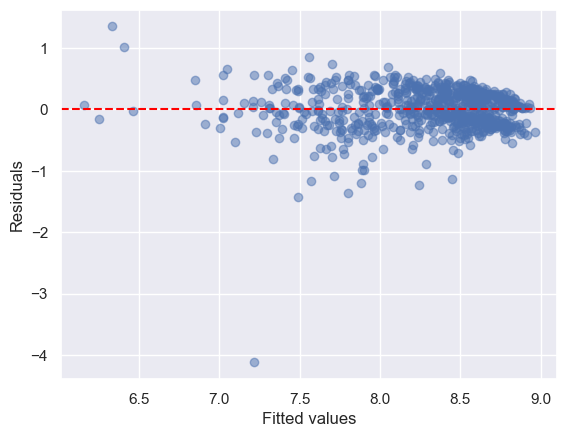

In [45]:
plt.scatter(model6.fittedvalues, model6.resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

Model 6 vælges som den færdige model

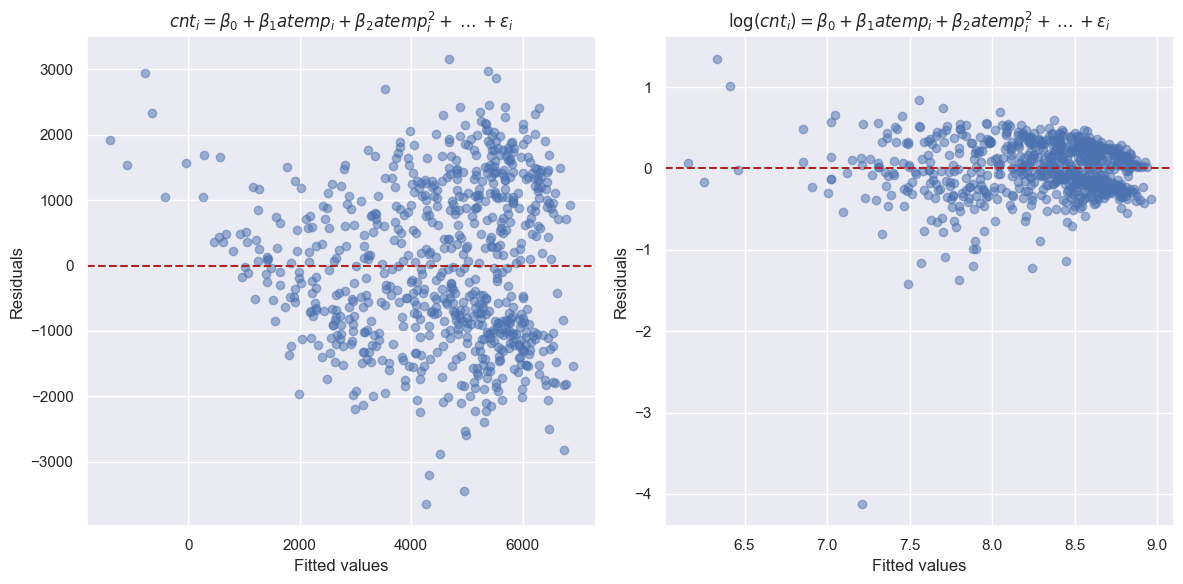

In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Model 5 ---
axes[0].scatter(model5.fittedvalues, model5.resid, alpha=0.5)
axes[0].axhline(0, linestyle='--', color='firebrick')
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title(
    r"$cnt_i = \beta_0 + \beta_1 atemp_i + \beta_2 atemp_i^2 + \dots + \varepsilon_i$",
    fontsize=12
)

# --- Model 6 ---
axes[1].scatter(model6.fittedvalues, model6.resid, alpha=0.5)
axes[1].axhline(0, linestyle='--', color='firebrick')
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")
axes[1].set_title(
    r"$\log(cnt_i) = \beta_0 + \beta_1 atemp_i + \beta_2 atemp_i^2 + \dots + \varepsilon_i$",
    fontsize=12
)

plt.tight_layout()
plt.savefig("residuals_compare.png", dpi=300, bbox_inches='tight')
plt.show()

# d) Elasticitet

$$E_x=\frac{\beta y}{\beta x}\cdot \frac{x}{y}$$

$$E_x=\frac{\beta log(y)}{\beta x}\cdot x$$

$$E_x=\beta_1 \cdot x$$

In [47]:
# Mean values
mean_atemp = df['atemp'].mean()
mean_hum = df['hum'].mean()
mean_windspeed = df['windspeed'].mean()

# Coefficients from model6
b_atemp = model6.params['atemp']
b_atemp2 = model6.params['I(atemp ** 2)']
b_hum = model6.params['hum']
b_windspeed = model6.params['windspeed']

# Elasticities evaluated at sample means
E_atemp = (b_atemp + 2 * b_atemp2 * mean_atemp) * mean_atemp
E_hum = b_hum * mean_hum
E_windspeed = b_windspeed * mean_windspeed

print("Elasticity atemp:", E_atemp)
print("Elasticity hum:", E_hum)
print("Elasticity windspeed:", E_windspeed)

Elasticity atemp: 1.1470838725294852
Elasticity hum: -0.6587889115166319
Elasticity windspeed: -0.18376634019870428


Lineær model (dummy)

$E_{Y,X_k}=\frac{\Delta Y}{Y} = \beta_k \frac{1}{Y}$


Pseudo-elasticitet (log(Y))

$exp(\beta_k)-1$

In [48]:
# Pseudo-elasticiteter for diskrete variable
dummy_vars = ['weathersit_3', 'season_3', 'season_4']

dummy_effects = pd.DataFrame({
    'Variable': dummy_vars,
    'Coefficient': [model6.params[v] for v in dummy_vars],
    'Effect (%)': [(np.exp(model6.params[v]) - 1) * 100 for v in dummy_vars]
})

display(dummy_effects)

,Variable,Coefficient,Effect (%)
0,weathersit_3,-0.903132,-59.470184
1,season_3,1.490640,343.993555
2,season_4,0.271899,31.245408
